##  Install & Imports:

In [1]:
# Cell 1
!pip install emoji loguru -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
import warnings
warnings.filterwarnings('ignore')

print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.0 MB/s eta 0:00:00
✅ Done


## preprocessor class:

In [2]:
# Cell 2 — Preprocessor Class
import re
import emoji
from typing import Optional

class HinglishPreprocessor:
    def __init__(
        self,
        remove_urls=True,
        remove_mentions=True,
        remove_hashtags=False,
        remove_emojis=False,
        lowercase=True,
        normalize_whitespace=True,
        min_length=3,
    ):
        self.remove_urls = remove_urls
        self.remove_mentions = remove_mentions
        self.remove_hashtags = remove_hashtags
        self.remove_emojis = remove_emojis
        self.lowercase = lowercase
        self.normalize_whitespace = normalize_whitespace
        self.min_length = min_length

        self._url_pattern = re.compile(
            r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
        )
        self._mention_pattern    = re.compile(r'@\w+')
        self._hashtag_pattern    = re.compile(r'#(\w+)')
        self._repeated_char      = re.compile(r'(.)\1{2,}')
        self._repeated_punct     = re.compile(r'([!?.]){2,}')
        self._whitespace_pattern = re.compile(r'\s+')

    def clean(self, text: str) -> Optional[str]:
        if not isinstance(text, str):
            return None

        if self.remove_urls:
            text = self._url_pattern.sub(' ', text)
        if self.remove_mentions:
            text = self._mention_pattern.sub(' ', text)

        # Hashtags: keep word, remove #
        if self.remove_hashtags:
            text = self._hashtag_pattern.sub(' ', text)
        else:
            text = self._hashtag_pattern.sub(r'\1', text)

        # Emojis
        if self.remove_emojis:
            text = emoji.replace_emoji(text, replace='')
        else:
            text = emoji.demojize(text)  # 😂 → :face_with_tears_of_joy:

        if self.lowercase:
            text = text.lower()

        text = self._repeated_char.sub(r'\1\1', text)
        text = self._repeated_punct.sub(r'\1', text)

        if self.normalize_whitespace:
            text = self._whitespace_pattern.sub(' ', text).strip()

        if len(text) < self.min_length:
            return None

        return text

    def clean_batch(self, texts: list, verbose=True) -> list:
        cleaned, failed = [], 0
        for text in texts:
            result = self.clean(text)
            cleaned.append(result)
            if result is None:
                failed += 1
        if verbose:
            print(f"✅ Cleaned {len(texts)} texts | Dropped: {failed}")
        return cleaned

print("✅ Preprocessor class ready")

✅ Preprocessor class ready


## Load data:

In [3]:
# Cell 3 — Load clean data from previous notebook output
# If continuing from EDA notebook output:
df = pd.read_csv('/kaggle/input/datasets/sharduldhekane/code-mixed-hinglish-hate-speech-detection-dataset/combined_hate_speech_dataset.csv')
df = df.rename(columns={'hate_label': 'label'})
df = df[['text', 'label', 'profanity_score', 'language', 'text_length', 'word_count']].copy()
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'])

print(f"Loaded: {df.shape}")
print(df['label'].value_counts())

Loaded: (29539, 6)
label
0    15818
1    13721
Name: count, dtype: int64


## Run preprocessing:

In [4]:
# Cell 4 — Apply preprocessing
preprocessor = HinglishPreprocessor()

print("Running preprocessing pipeline...")
df['text_clean'] = preprocessor.clean_batch(df['text'].tolist())

# Check how many got dropped
before = len(df)
df_clean = df.dropna(subset=['text_clean']).copy()
after = len(df_clean)

print(f"\nDropped {before - after} rows (too short after cleaning)")
print(f"Remaining: {after}")

# Show side by side comparison
print("\n--- Sample Before vs After ---")
for i in range(5):
    print(f"\nORIGINAL : {df['text'].iloc[i]}")
    print(f"CLEANED  : {df['text_clean'].iloc[i]}")

Running preprocessing pipeline...
✅ Cleaned 29539 texts | Dropped: 6

Dropped 6 rows (too short after cleaning)
Remaining: 29533

--- Sample Before vs After ---

ORIGINAL : Knowing ki Vikas kitna samjhata hai Priyanka aur Itch Guard Luv ko, usne bola tha Ben wali baat me ab Sallu ne bhi agree kiya!
CLEANED  : knowing ki vikas kitna samjhata hai priyanka aur itch guard luv ko, usne bola tha ben wali baat me ab sallu ne bhi agree kiya!

ORIGINAL : I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani
CLEANED  : i am muhajir . aur mere lye sab se pehly pakistan he . agr 10 lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye . proud to be a muhajir and pakistani

ORIGINAL : Doctor  sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling  khelo, aur maje lo

## Verify label balance preserved:

Label distribution AFTER cleaning:
label
0    15817
1    13716
Name: count, dtype: int64

Imbalance ratio: 1.15x


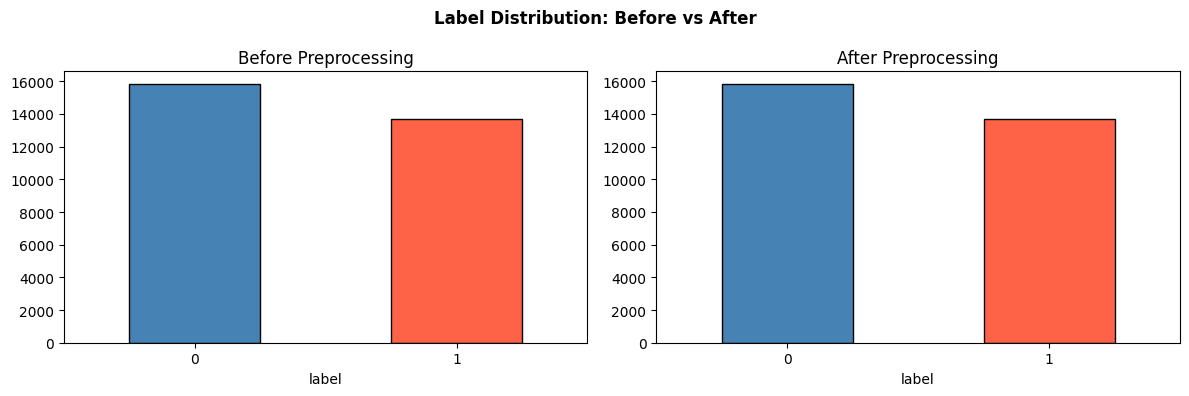

In [5]:
# Cell 5 — Check label distribution after cleaning
print("Label distribution AFTER cleaning:")
print(df_clean['label'].value_counts())
print(f"\nImbalance ratio: {df_clean['label'].value_counts().max() / df_clean['label'].value_counts().min():.2f}x")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
df['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue','tomato'], edgecolor='black'
)
axes[0].set_title('Before Preprocessing')
axes[0].tick_params(rotation=0)

# After
df_clean['label'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['steelblue','tomato'], edgecolor='black'
)
axes[1].set_title('After Preprocessing')
axes[1].tick_params(rotation=0)

plt.suptitle('Label Distribution: Before vs After', fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_label_check.png', dpi=150)
plt.show()

## Text length change analysis:

Text length change after preprocessing:
       text_length  text_clean_length  length_reduction_pct
count      29533.0            29533.0               29533.0
mean         150.5              148.7                   1.6
std          189.7              189.8                   5.8
min            3.0                3.0                 -12.2
25%           53.0               52.0                   0.0
50%           94.0               91.0                   0.0
75%          167.0              164.0                   0.5
max         1926.0             1926.0                  81.9

Avg length reduction: 1.6%


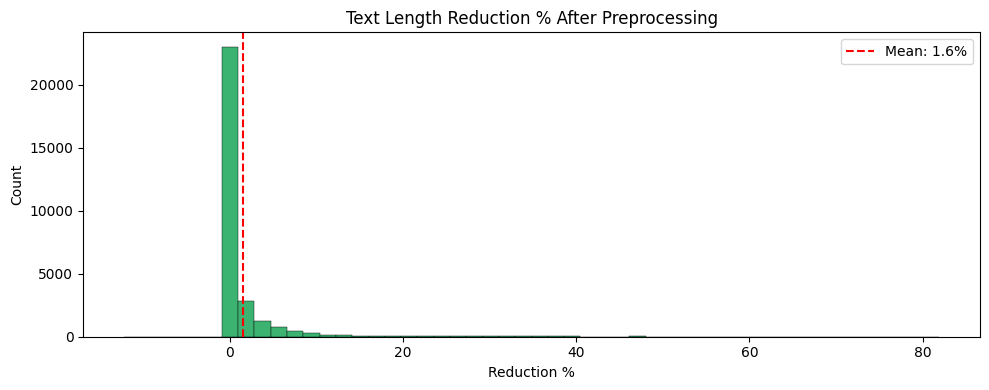

In [6]:
# Cell 6 — How much did preprocessing change text length?
df_clean['text_clean_length'] = df_clean['text_clean'].str.len()
df_clean['length_reduction'] = df_clean['text_length'] - df_clean['text_clean_length']
df_clean['length_reduction_pct'] = (df_clean['length_reduction'] / df_clean['text_length'] * 100).round(1)

print("Text length change after preprocessing:")
print(df_clean[['text_length', 'text_clean_length', 'length_reduction_pct']].describe().round(1))

print(f"\nAvg length reduction: {df_clean['length_reduction_pct'].mean():.1f}%")

plt.figure(figsize=(10, 4))
plt.hist(df_clean['length_reduction_pct'], bins=50, color='mediumseagreen', edgecolor='black', linewidth=0.3)
plt.title('Text Length Reduction % After Preprocessing')
plt.xlabel('Reduction %')
plt.ylabel('Count')
plt.axvline(df_clean['length_reduction_pct'].mean(), color='red', linestyle='--',
            label=f'Mean: {df_clean["length_reduction_pct"].mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.savefig('length_reduction.png', dpi=150)
plt.show()

## Train/Val/Test split:

In [7]:
# Cell 7 — Stratified Split
from sklearn.model_selection import train_test_split

SEED = 42

# Use cleaned text
df_final = df_clean[['text_clean', 'label', 'profanity_score']].copy()
df_final = df_final.rename(columns={'text_clean': 'text'})

# Step 1: 80% train_val / 20% test
train_val, test_df = train_test_split(
    df_final,
    test_size=0.20,
    random_state=SEED,
    stratify=df_final['label']
)

# Step 2: 87.5% train / 12.5% val (= 70% / 10% of total)
train_df, val_df = train_test_split(
    train_val,
    test_size=0.125,
    random_state=SEED,
    stratify=train_val['label']
)

print("✅ Split complete:")
print(f"  Train : {len(train_df)} ({len(train_df)/len(df_final)*100:.1f}%)")
print(f"  Val   : {len(val_df)}  ({len(val_df)/len(df_final)*100:.1f}%)")
print(f"  Test  : {len(test_df)}  ({len(test_df)/len(df_final)*100:.1f}%)")

print("\nLabel distribution per split:")
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split['label'].value_counts()
    print(f"  {name}: NOT={counts[0]} | HOF={counts[1]} | ratio={counts.max()/counts.min():.2f}x")

✅ Split complete:
  Train : 20672 (70.0%)
  Val   : 2954  (10.0%)
  Test  : 5907  (20.0%)

Label distribution per split:
  Train: NOT=11071 | HOF=9601 | ratio=1.15x
  Val: NOT=1582 | HOF=1372 | ratio=1.15x
  Test: NOT=3164 | HOF=2743 | ratio=1.15x


## Save all splits:

In [8]:
# Cell 8 — Save splits
train_df.to_csv('/kaggle/working/train.csv', index=False)
val_df.to_csv('/kaggle/working/val.csv', index=False)
test_df.to_csv('/kaggle/working/test.csv', index=False)
df_final.to_csv('/kaggle/working/full_clean.csv', index=False)

print("✅ Saved:")
print("  /kaggle/working/train.csv")
print("  /kaggle/working/val.csv")
print("  /kaggle/working/test.csv")
print("  /kaggle/working/full_clean.csv")

print("\n📊 PREPROCESSING SUMMARY")
print("="*40)
print(f"Original samples : {len(df)}")
print(f"After cleaning   : {len(df_final)}")
print(f"Train            : {len(train_df)}")
print(f"Val              : {len(val_df)}")
print(f"Test             : {len(test_df)}")

✅ Saved:
  /kaggle/working/train.csv
  /kaggle/working/val.csv
  /kaggle/working/test.csv
  /kaggle/working/full_clean.csv

📊 PREPROCESSING SUMMARY
Original samples : 29539
After cleaning   : 29533
Train            : 20672
Val              : 2954
Test             : 5907
